In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import ElasticNet
from sklearn.feature_selection import SelectFromModel

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [32]:
df = pd.read_csv("NIFTY50.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select available columns (remove Volume if not present)
df.columns = df.columns.str.strip()
df = df[['Open', 'High', 'Low', 'Close']]

# 🔥 IMPORTANT FIX
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Remaining NaNs in dataframe:")
print(df.isna().sum())

Remaining NaNs in dataframe:
Open     0
High     0
Low      0
Close    0
dtype: int64


In [33]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

In [34]:
def create_sequences(data, target_column, time_steps=60):
    X, y = [], []
    
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, target_column])
        
    return np.array(X), np.array(y)

target_col_index = df.columns.get_loc("Close")

X, y = create_sequences(scaled_df.values, target_col_index)

In [35]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [36]:
# Separate features and target
X_enet = scaled_df.drop(columns=["Close"]).values
y_enet = scaled_df["Close"].values

elastic = ElasticNet(alpha=0.0001, l1_ratio=0.5)
elastic.fit(X_enet, y_enet)

# Select non-zero coefficient features
selected_indices = np.where(elastic.coef_ != 0)[0]

print("Selected feature indices:", selected_indices)

selected_columns = scaled_df.drop(columns=["Close"]).columns[selected_indices]
print("Selected columns:", selected_columns)

# Keep selected features + target
scaled_selected = scaled_df[list(selected_columns) + ["Close"]]

Selected feature indices: [0 1 2]
Selected columns: Index(['Open', 'High', 'Low'], dtype='object')


In [37]:
target_col_index = scaled_selected.columns.get_loc("Close")

X, y = create_sequences(scaled_selected.values, target_col_index)

In [38]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [39]:
n_features = X_train.shape[2]

print("Training shape:", X_train.shape)
print("Number of features:", n_features)

Training shape: (2400, 60, 4)
Number of features: 4


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(60, n_features)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

/Users/krish/stock_ml/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,753 (198.25 KB)

 Trainable params: 50,753 (198.25 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0025 - val_loss: 2.6246e-04
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0010 - val_loss: 2.4025e-04
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 9.3227e-04 - val_loss: 2.2257e-04
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.7035e-04 - val_loss: 2.3401e-04
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.4878e-04 - val_loss: 2.1883e-04
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.5982e-04 - val_loss: 1.8728e-04
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.1359e-04 - val_loss: 1.8445e-04
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.6197e-04 - val_loss: 1.8322e-04
Epoch 9/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.5316e-04 - val_loss: 1.7997e-04
Epoch 10/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.2182e-04 - val_loss: 2.1470e-04
Epoch 11/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.0829e-04 - val_

In [25]:
predictions = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [42]:
import numpy as np

# Create empty array for inverse scaling
temp = np.zeros((len(predictions), scaled_selected.shape[1]))
temp[:, target_col_index] = predictions.flatten()

predictions_inverse = scaler.inverse_transform(temp)[:, target_col_index]

# Same for y_test
temp2 = np.zeros((len(y_test), scaled_selected.shape[1]))
temp2[:, target_col_index] = y_test

y_test_inverse = scaler.inverse_transform(temp2)[:, target_col_index]

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_inverse, predictions_inverse))
mae = mean_absolute_error(y_test_inverse, predictions_inverse)
r2 = r2_score(y_test_inverse, predictions_inverse)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 1.9614263907856493
MAE: 0.9986574948007569
R2: 0.9615250189086318


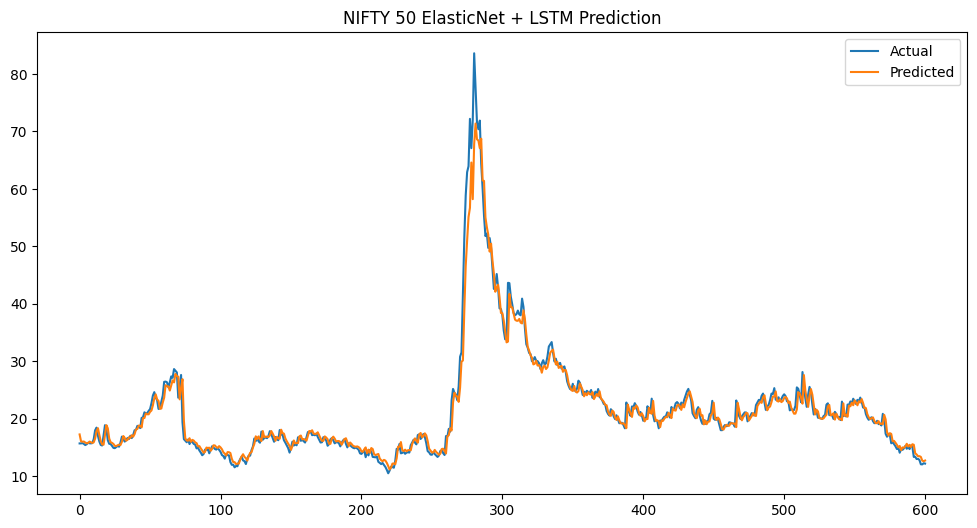

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_inverse, label="Actual")
plt.plot(predictions_inverse, label="Predicted")
plt.legend()
plt.title("NIFTY 50 ElasticNet + LSTM Prediction")
plt.show()